# Classification ensembles

Adapted by <alberto.suarez@uam.es>

from
Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.

In [1]:
%load_ext autoreload
%autoreload 2

from collections import namedtuple

import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (VotingClassifier,
                              BaggingClassifier,
                              RandomForestClassifier, 
                              ExtraTreesClassifier,
                              AdaBoostClassifier,
                              GradientBoostingClassifier)

from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline

# Plotting utilities
import utilities.plot_utilities as pltu

## Ensembles of neural networks

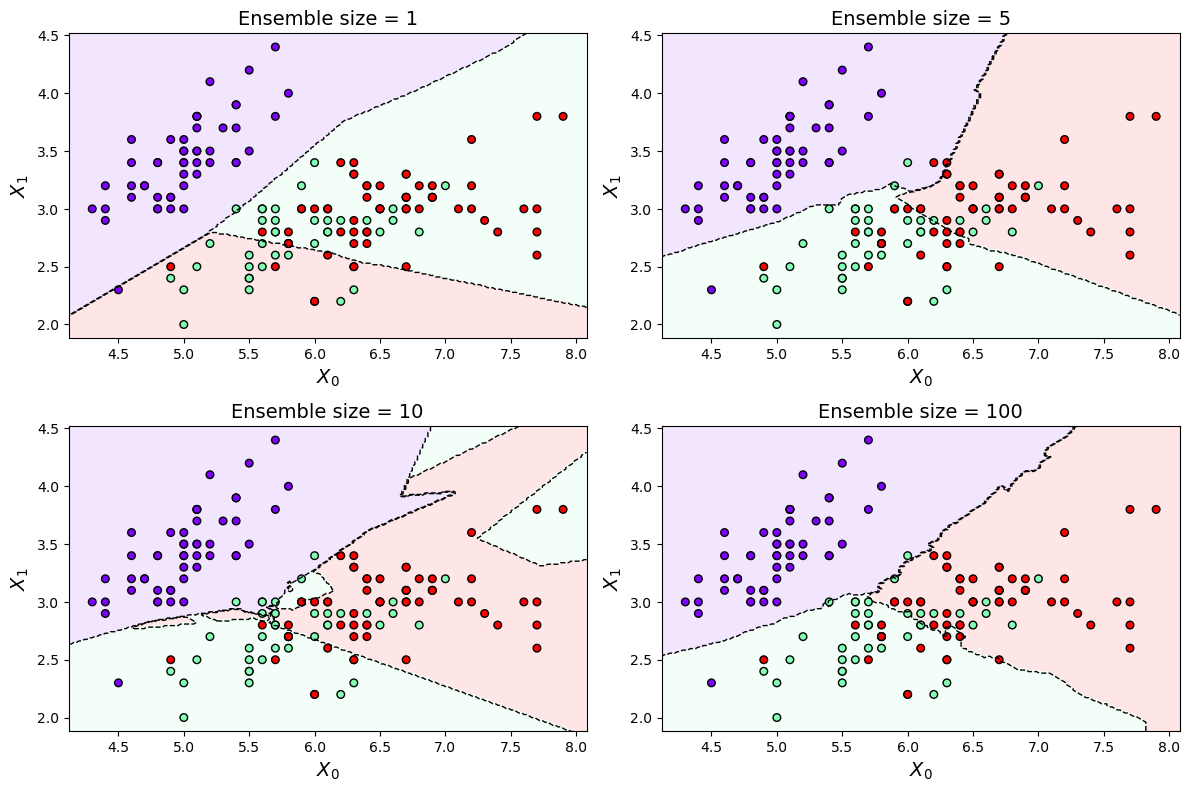

In [2]:
# Load dataset
dataset = datasets.load_iris()

feature_indices = [0, 1]
X = dataset.data[:, feature_indices]  
y = dataset.target

scaler = StandardScaler()    

ensemble_sizes = [1, 5, 10, 100]

# Variability due to initialization of synaptic weights in training phase.
hidden_layer_sizes=(5,) # Weak classifer (few neurons in hidden layer)
randomized_classifier =  MLPClassifier(hidden_layer_sizes=(5,))


# Comment to view warnings 
import warnings
warnings.filterwarnings('ignore')

# Plot setup 
n_rows_plot = 2
n_columns_plot = 2

fig, axs = plt.subplots(n_rows_plot, n_columns_plot, figsize=(12, 8))


for n, n_estimators in enumerate(ensemble_sizes):

    ensemble_members = []
    for i in range(n_estimators):
        ensemble_member = randomized_classifier.fit(X, y)
        ensemble_members.append(('{}th ensemble member'.format(i),
                                 ensemble_member))    

    ensemble_classifier = VotingClassifier(estimators=ensemble_members,
                                          voting='hard')
     
    pipeline = Pipeline([('scaler', scaler),
                         ('Ensemble Classifier', ensemble_classifier)])

    pipeline.fit(X, y)

    # Plot decision regions
    n_row_plot = n // n_columns_plot    
    n_column_plot = n % n_columns_plot
  
    ax = axs[n_row_plot, n_column_plot]
 
    pltu.plot_2D_decision_regions(X, y, 
                                  pipeline.predict, 
                                  ax=ax,
                                  decision_levels=[-1, 0, 1],
                                  cmap = plt.cm.rainbow,
                                  alpha_light=0.1)
    
    ax.set_title('Ensemble size = {}'.format(n_estimators), fontsize=14)

fig.tight_layout(pad=1.0)
        

## Bagging ensembles

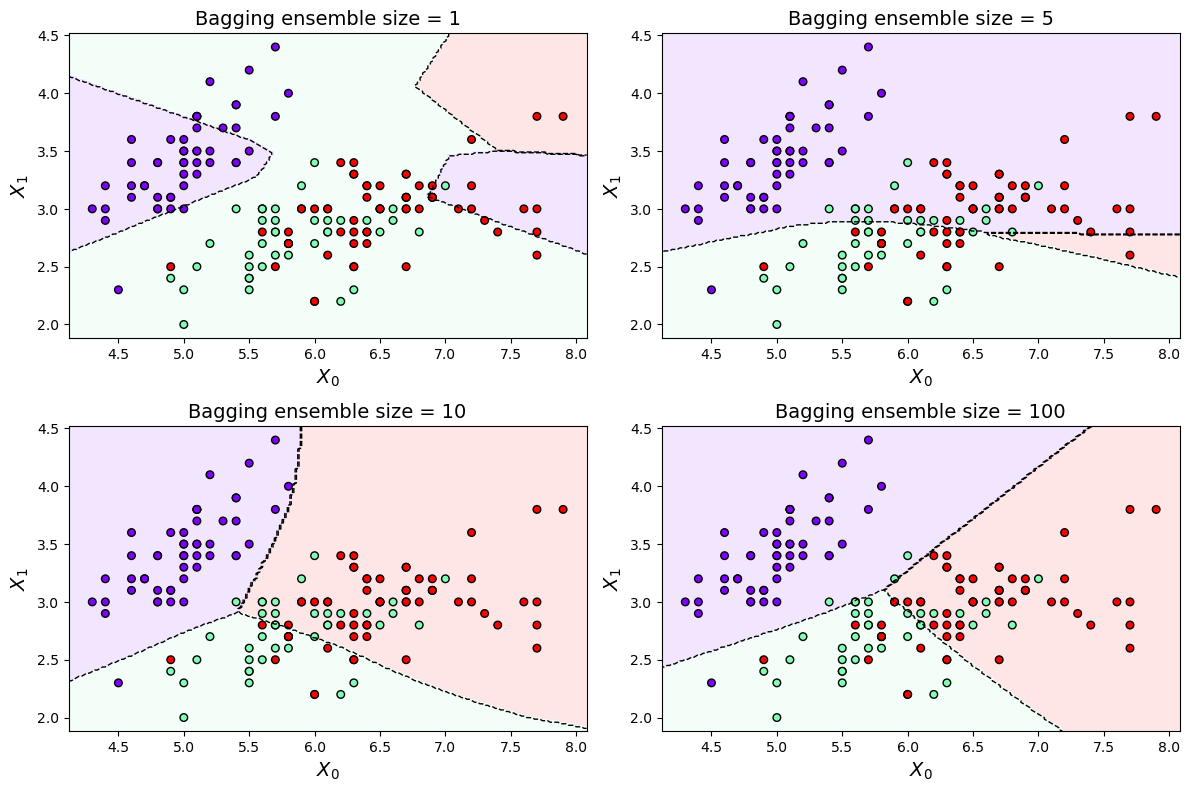

In [3]:
# Load dataset
dataset = datasets.load_iris()

feature_indices = [0, 1]
X = dataset.data[:, feature_indices]  
y = dataset.target

scaler = StandardScaler()    

ensemble_sizes = [1, 5, 10, 100]


# Base classifier
hidden_layer_sizes = (5,) # Weak classifer (few neurons in hidden layer)
base_estimator =  MLPClassifier(hidden_layer_sizes=hidden_layer_sizes)

# Plot setup 
n_rows_plot = 2
n_columns_plot = 2

fig, axs = plt.subplots(n_rows_plot, n_columns_plot, figsize=(12, 8))


for n, n_estimators in enumerate(ensemble_sizes):

    bagging_ensemble = BaggingClassifier(base_estimator=base_estimator, 
                                         n_estimators=n_estimators)
    
    pipeline = Pipeline([('scaler', scaler),
                         ('Begging ensemble Classifier', bagging_ensemble)])

    pipeline.fit(X, y)

    # Plot decision regions
    n_row_plot = n // n_columns_plot    
    n_column_plot = n % n_columns_plot
  
    ax = axs[n_row_plot, n_column_plot]
 
    pltu.plot_2D_decision_regions(X, y, 
                                  pipeline.predict, 
                                  ax=ax,
                                  decision_levels=[-1, 0, 1],
                                  cmap = plt.cm.rainbow,
                                  alpha_light=0.1)
    
    ax.set_title('Bagging ensemble size = {}'.format(n_estimators), fontsize=14)

fig.tight_layout(pad=1.0)


## Ensembles of decision trees

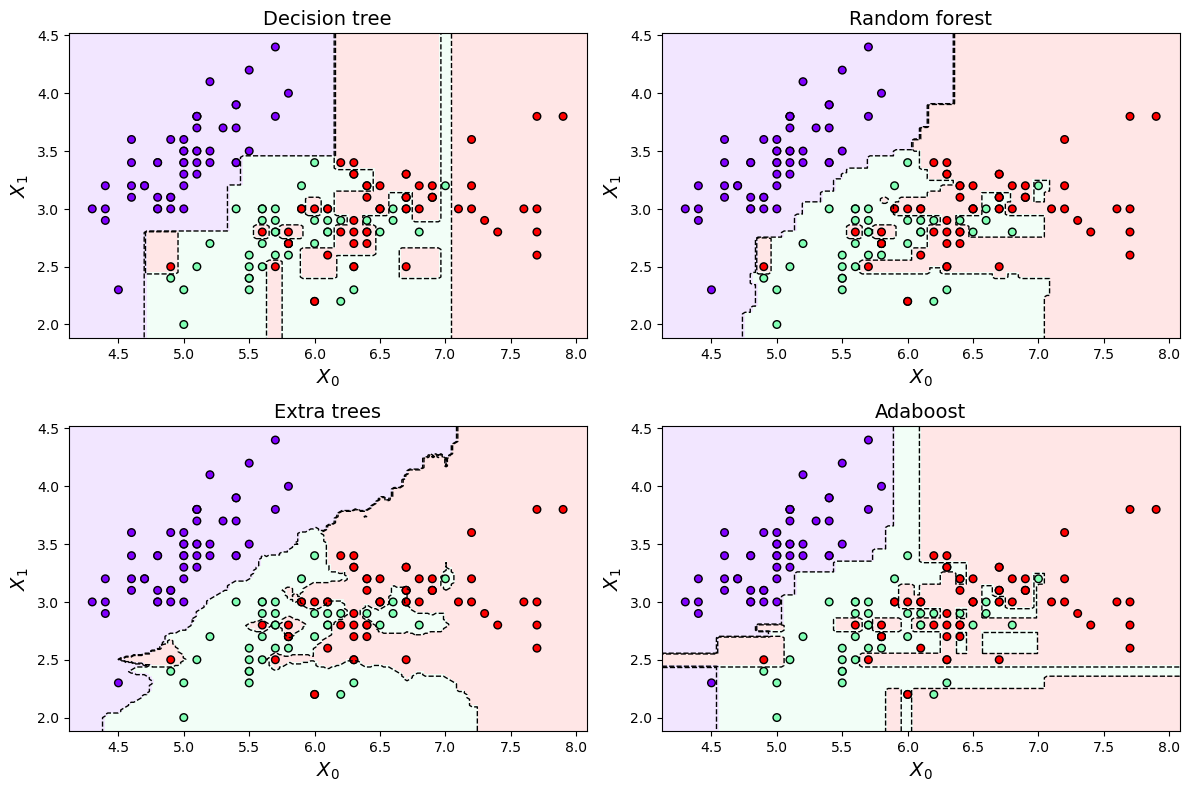

In [4]:
# Load dataset
dataset = datasets.load_iris()

feature_indices = [0, 1]
X = dataset.data[:, feature_indices]  
y = dataset.target

n_estimators = 101

scaler = StandardScaler()    

Classifier = namedtuple('Classifier','name classifier')

classifiers = [Classifier('Decision tree', 
                          DecisionTreeClassifier(max_depth=None)),
               Classifier('Random forest', 
                          RandomForestClassifier(n_estimators=n_estimators)),
               Classifier('Extra trees', 
                          ExtraTreesClassifier(n_estimators=n_estimators)),
               Classifier('Adaboost', 
                          AdaBoostClassifier(DecisionTreeClassifier(max_depth=3),
                          n_estimators=n_estimators))]

# Plot setup 
n_rows_plot = 2
n_columns_plot = 2

fig, axs = plt.subplots(n_rows_plot, n_columns_plot, figsize=(12, 8))


for n, clf in enumerate(classifiers):
    
    # Initialize instance of Pipeline
    
    pipeline = Pipeline([('scaler', scaler),
                         (clf.name, clf.classifier)])

    pipeline.fit(X, y)

    # Plot decision regions
    n_row_plot = n // n_columns_plot    
    n_column_plot = n % n_columns_plot
  
    ax = axs[n_row_plot, n_column_plot]
 
    pltu.plot_2D_decision_regions(X, y, 
                                  pipeline.predict, 
                                  ax=ax,
                                  decision_levels=[-1, 0, 1],
                                  cmap = plt.cm.rainbow,
                                  alpha_light=0.1)


    ax.set_title(clf.name, fontsize=14)

fig.tight_layout(pad=1.0)


## Dependence on ensemble size

In [ ]:
# To measure time costs
from timeit import default_timer as timer


# Load dataset
dataset = datasets.load_digits()

X = dataset.data  
y = dataset.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, shuffle=True)

scaler = StandardScaler()    

bagging_ensemble = BaggingClassifier(base_estimator=base_estimator, 
                                         n_estimators=n_estimators)
   
n_estimators = 101

base_estimator = DecisionTreeClassifier(max_depth=3)


classifiers = [Classifier('Bagging ensemble',
                          BaggingClassifier(base_estimator=base_estimator, 
                                         n_estimators=n_estimators)),
               Classifier('Random forest', 
                          RandomForestClassifier(n_estimators=n_estimators)),
               Classifier('Adaboost', 
                          AdaBoostClassifier(base_estimator=base_estimator,
                                             n_estimators=n_estimators)),
               Classifier('Gradient boosting',
                          GradientBoostingClassifier(n_estimators=n_estimators))
              ]


# Plot setup 
n_rows_plot = 2
n_columns_plot = 2

fig, axs = plt.subplots(n_rows_plot, n_columns_plot, figsize=(12, 8))

max_ensemble_size = 201
ensemble_sizes = range(1, max_ensemble_size, 2)

for n, clf in enumerate(classifiers):
 
    pipeline = Pipeline([('scaler', scaler),
                         (clf.name, clf.classifier)])

    error_train = np.empty(len(ensemble_sizes))
    error_test = np.empty(len(ensemble_sizes))
    if(hasattr(clf.classifier, 'oob_score_')): # Out-of-bag
        error_oob = np.empty(len(ensemble_sizes))
    
    time_start = timer()

    for i, n_estimators in enumerate(ensemble_sizes):
        
        np.random.seed(0)
            
        clf.classifier.set_params(n_estimators=n_estimators)
       
        pipeline.fit(X_train, y_train)
        
        y_train_pred = pipeline.predict(X_train)    
        error_train[i] = 1.0 - accuracy_score(y_train, y_train_pred)

        y_test_pred = pipeline.predict(X_test)    
        error_test[i] = 1.0 - accuracy_score(y_test, y_test_pred)        
        
        if(hasattr(clf.classifier, 'oob_score_')): 
            error_oob[i] = 1.0 - clf.classifier.oob_score_

       
    time_end = timer()

    print('{} [{:.2f} seconds]'.format(clf.name, time_end - time_start))  
        
    # Plot decision regions
    n_row_plot = n // n_columns_plot    
    n_column_plot = n % n_columns_plot
  
    ax = axs[n_row_plot, n_column_plot]
 
    ax.plot(ensemble_sizes, error_train, label = 'Training error')
    ax.plot(ensemble_sizes, error_test, label = 'Test error')
    if(hasattr(clf.classifier, 'oob_score_')):
       ax.plot(ensemble_sizes, error_oob, label = 'Out-of_bag error')
           
    ax.set_xlabel('Ensemble size', fontsize=14)
    ax.set_ylabel('Error', fontsize=14)
    ax.set_title('{}  Test error = {:.2f} % '.format(clf.name, 
                                                     100.0*error_test[-1]),
                 fontsize=14)

    ax.legend()
    
fig.tight_layout(pad=1.0)


Bagging ensemble [32.86 seconds]
Random forest [14.21 seconds]


## What have we learned?

1. Ensemble methods can be used to pool the decisions of a collection of classifiers to yield a global prediction that, in general, is better than the individual ones.

2. Ensemble methods work best with weak and randomized classifiers (e.g. decision trees).

3. Random forest and gradient boosting are among the best off-the-shelf classifiers for unstructured data; that is, excluding data such as images, for which deep architectures have the best performance, provided that large amounts of training data are available.

4. Adaboost is in general fairly good ensemble algorithm. However, it is not robust to the presence of noise in the class labels. In the course of the interations, large weights tend to be assigned to these examples, which distorts the classification problem that is being considered.

5. Ensembles composed of independent classifiers, such as bagging or random forest are amenable to paralellization: each tree can be trained in a different process. Testing can also be sped up by parallelization and dynamic pruning [D. Hernández-Lobato, G. Martínez-Muñoz and A. Suárez, "Statistical Instance-Based Pruning in Ensembles of Independent Classifiers," in IEEE Transactions on Pattern Analysis and Machine Intelligence, vol. 31, no. 2, pp. 364-369, Feb. 2009, doi: 10.1109/TPAMI.2008.204.]


## For further exploration:

1. An extensive evaluation of different classifiers in a large number of small and medium datasets can be found in the article

Manuel Fernández-Delgado, Eva Cernadas, Senén Barro, and Dinani Amorim. 2014. Do we need hundreds of classifiers to solve real world classification problems? J. Mach. Learn. Res. 15, 1 (January 2014), 3133–3181.

https://jmlr.org/papers/volume15/delgado14a/delgado14a.pdf


## Exercises

1. Investigate what the out-of-bag error is. Make a plot for the out-of-bag error as a function of the size of the ensemble for those ensembles that have such property. Is it a reliable estimate of the test error?

2. The implementation made is rather inefficient: At each stage the ensemble classifiers are generated anew. Build a single ensemble and then consider a nested sequence of subensembles. A subensemble in such sequence is composed of all the members of the preceding subensemble plus a new predictor.
